# Tesla Stock Price Prediction

This notebook builds and compares SimpleRNN and LSTM models for Tesla closing-price forecasting across 1-day, 5-day, and 10-day horizons.

The workflow covers loading the data, cleaning missing values, exploratory analysis, sequence preparation, GridSearchCV-based tuning, model training, and final comparison.

## Project Objective

- Use Tesla historical price data to model the closing price as a time series.
- Compare SimpleRNN and LSTM performance.
- Forecast 1 day, 5 days, and 10 days ahead using a direct multi-horizon approach.
- Tune LSTM hyperparameters with GridSearchCV.
- Evaluate the models using MSE, RMSE, MAE, MAPE, and R2.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from tsla_utils import (
    build_sequence_bundle,
    compare_models_for_horizon,
    load_tsla_data,
    missing_summary,
    prepare_target_series,
    run_lstm_grid_search,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [2]:
data = load_tsla_data('TSLA.csv')
target = prepare_target_series(data, target_column='Close')

print(f'Dataset shape: {data.shape}')
display(data.head())
display(missing_summary(data))
data.info()

Dataset shape: (2416, 6)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


,missing_count,missing_pct
Open,0,0.0
High,0,0.0
Low,0,0.0
Close,0,0.0
Adj Close,0,0.0
Volume,0,0.0


<class 'pandas.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


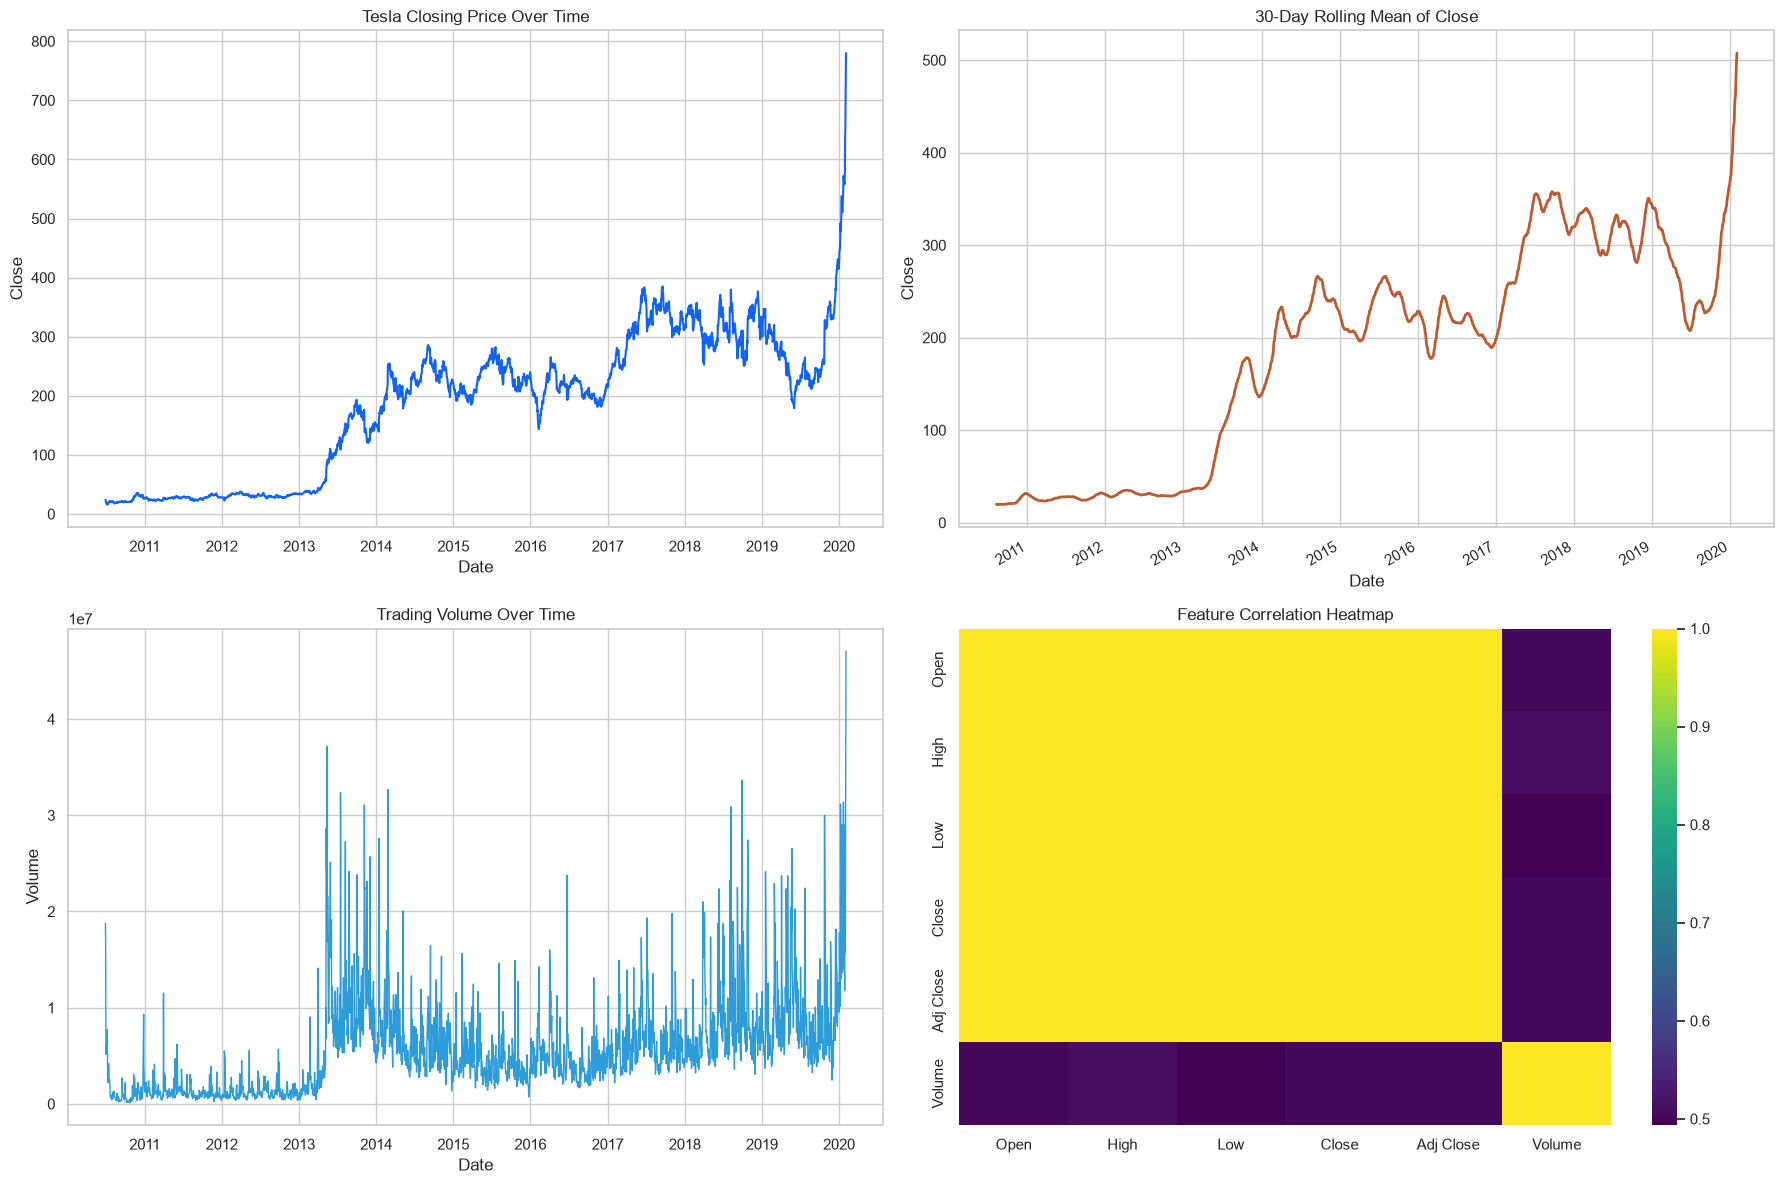

In [3]:
numeric_columns = data.select_dtypes(include=[np.number]).columns
corr = data[numeric_columns].corr()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].plot(target.index, target.values, color='#0F62FE', linewidth=1.5)
axes[0, 0].set_title('Tesla Closing Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Close')

target.rolling(30).mean().plot(ax=axes[0, 1], color='#BE5A30', linewidth=2)
axes[0, 1].set_title('30-Day Rolling Mean of Close')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Close')

if 'Volume' in data.columns:
    axes[1, 0].plot(data.index, data['Volume'], color='#2D9CDB', linewidth=1.0)
    axes[1, 0].set_title('Trading Volume Over Time')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Volume')
else:
    axes[1, 0].text(0.5, 0.5, 'Volume column not found', ha='center', va='center')
    axes[1, 0].axis('off')

sns.heatmap(corr, cmap='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()

In [4]:
lookback = 60
horizon_for_tuning = 1

bundle = build_sequence_bundle(target, lookback=lookback, horizon=horizon_for_tuning, test_size=0.2)
grid = run_lstm_grid_search(bundle.x_train, bundle.y_train, epochs=8, batch_size=32, cv_splits=3)

best_units = int(grid.best_params_.get('model__units', 64))
best_dropout = float(grid.best_params_.get('model__dropout', 0.2))
best_learning_rate = float(grid.best_params_.get('model__learning_rate', 1e-3))

print('Best parameters:', grid.best_params_)
print('Best CV score (negative MSE):', grid.best_score_)

Best parameters: {'model__dropout': 0.2, 'model__learning_rate': 0.001, 'model__units': 64}
Best CV score (negative MSE): -0.009050131758974742


In [ ]:
horizons = [1, 5, 10]
comparison_rows = []
horizon_results = {}
comparison_lookback = 30
comparison_epochs = 3
comparison_batch_size = 128

for horizon in horizons:
    results, bundle = compare_models_for_horizon(
        target,
        horizon=horizon,
        lookback=comparison_lookback,
        test_size=0.2,
        epochs=comparison_epochs,
        batch_size=comparison_batch_size,
        units=best_units,
        dropout=best_dropout,
        learning_rate=best_learning_rate,
        checkpoint_dir=None,
    )
    horizon_results[horizon] = results
    for model_name, payload in results.items():
        comparison_rows.append({
            'horizon': horizon,
            'model': model_name,
            **payload['metrics'],
        })

comparison_df = pd.DataFrame(comparison_rows).sort_values(['horizon', 'mse']).reset_index(drop=True)
display(comparison_df)

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
fig, axes = plt.subplots(len(horizons), 2, figsize=(18, 16), sharex=False)

for row_idx, horizon in enumerate(horizons):
    for col_idx, model_name in enumerate(['simple_rnn', 'lstm']):
        payload = horizon_results[horizon][model_name]
        ax = axes[row_idx, col_idx]
        ax.plot(payload['y_true'], label='Actual', linewidth=1.5, color='#111111')
        ax.plot(payload['y_pred'], label='Predicted', linewidth=1.5, color='#0F62FE')
        ax.set_title(f'{model_name.upper()} | Horizon {horizon} day(s)')
        ax.set_xlabel('Test Observations')
        ax.set_ylabel('Close')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()

## Conclusion

Use the comparison table above to identify the best architecture for each horizon. In most stock-price forecasting problems, LSTM typically performs better than SimpleRNN because it retains long-range temporal dependencies more effectively.

Key takeaways for the report:

- Missing values should be handled with time-aware interpolation and forward/backward fill rather than global mean imputation.
- The target is the closing price, and sequence generation preserves temporal order to avoid leakage.
- GridSearchCV provides a reproducible way to optimize LSTM units, dropout, and learning rate.
- Short-horizon forecasts are usually easier than 5-day or 10-day forecasts because uncertainty compounds as the horizon grows.
- The notebook can be extended with exogenous features such as volume trends, macroeconomic indicators, or sentiment signals.